<a href="https://colab.research.google.com/github/sofiajvallejos/tfi-aprendizaje-maquina-2026/blob/main/TFI_Prestaciones_Enfermeria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Integrador — Introducción al Aprendizaje de Máquina
## Doctorado en Informática (UNNE–UNaM–UTN FRRe)
### Docentes: Dr. Eduardo Zamudio, Dra. Nancy Ganz

**Integrantes:** Sofía Vallejos, Cecilia Soto

**Dataset:** Prestaciones de Enfermería — Portal de Datos Abiertos, Municipalidad de Corrientes (7408 registros)

**Objetivo:** Aplicar algoritmos de regresión, clasificación y máquinas de vector soporte sobre un
caso real de gestión sanitaria municipal, comparando el desempeño de distintos modelos sobre un
mismo problema de regresión y de clasificación.

## 1. Comprensión y carga de datos

El dataset contiene registros mensuales de prestaciones de enfermería en 34 centros de salud (SAPS)
de la Municipalidad de Corrientes, entre enero de 2023 y mayo de 2026. Cada fila indica, para un
centro, un mes/año y un tipo de prestación (ej. control de tensión arterial, glucemia, curaciones),
la **cantidad de consultas** realizadas (`consulta_cantidad`).

Esta variable será nuestro **target**:
- Como **variable continua**, para la tarea de regresión.
- **Discretizada por la mediana**, para las tareas de clasificación binaria.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('prestaciones_enfermeria_original.csv')
print(df.shape)
df.head()

(7408, 9)


,saps,fecha,fecha_mes,fecha_anio,id_servicio,prestacion_categoria,prestacion_tipo,consulta_cantidad,barrio_operativo
0,PUJOL,2023-01-01,1,2023,4,ENFERMERIA,CONTROL TENSION ARTERIAL,41.0,NaN
1,PUJOL,2023-01-01,1,2023,4,ENFERMERIA,TEMPERATURA,19.0,NaN
2,PUJOL,2023-01-01,1,2023,4,ENFERMERIA,GLUCEMIA,9.0,NaN
3,PUJOL,2023-01-01,1,2023,4,ENFERMERIA,NEBULIZACIONES,4.0,NaN
4,PUJOL,2023-01-01,1,2023,4,ENFERMERIA,PESO Y TALLA,98.0,NaN


In [3]:
# La columna barrio_operativo está 100% vacía en este recorte del dataset: se descarta.
# Hay un único registro con consulta_cantidad faltante: se descarta (no es imputable con criterio sólido).
df = df.drop(columns=['barrio_operativo'])
df = df.dropna(subset=['consulta_cantidad']).copy()
df['fecha'] = pd.to_datetime(df['fecha'])

print(f"Registros finales: {len(df)}")
df.describe(include='all').T

Registros finales: 7407


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
saps,7407,34,ITATI,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,7407,NaN,NaN,NaN,2024-06-15 13:24:28.286756096,2023-01-01 00:00:00,2023-08-01 00:00:00,2024-05-01 00:00:00,2025-05-01 00:00:00,2026-05-01 00:00:00,NaN
fecha_mes,7407.0,NaN,NaN,NaN,6.014311,1.0,3.0,6.0,9.0,12.0,3.352833
fecha_anio,7407.0,NaN,NaN,NaN,2024.039152,2023.0,2023.0,2024.0,2025.0,2026.0,0.981647
id_servicio,7407.0,NaN,NaN,NaN,4.046173,4.0,4.0,4.0,4.0,10.0,0.524348
prestacion_categoria,7407,2,ENFERMERIA,7350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prestacion_tipo,7407,18,CONTROL TENSION ARTERIAL,982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
consulta_cantidad,7407.0,NaN,NaN,NaN,101.121642,0.0,14.0,44.0,128.0,2890.0,150.217654


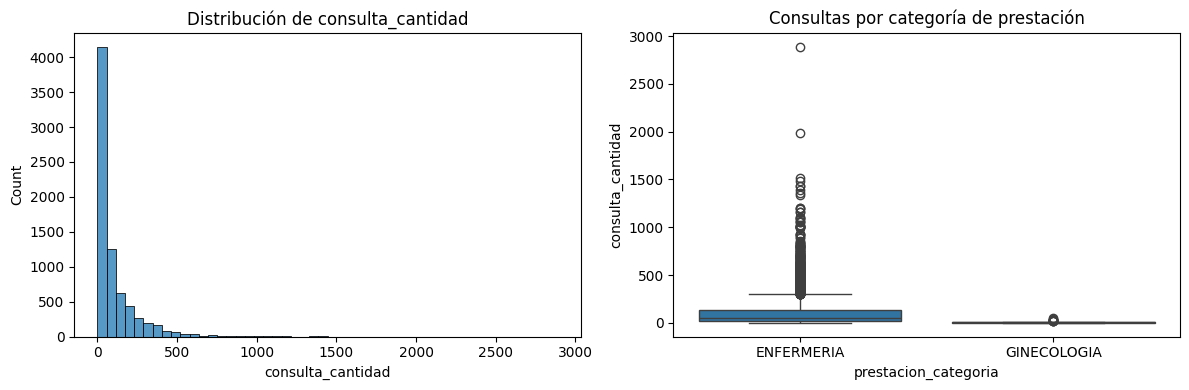

count    7407.000000
mean      101.121642
std       150.217654
min         0.000000
25%        14.000000
50%        44.000000
75%       128.000000
max      2890.000000
Name: consulta_cantidad, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['consulta_cantidad'], bins=50, ax=axes[0])
axes[0].set_title('Distribución de consulta_cantidad')
sns.boxplot(x=df['prestacion_categoria'], y=df['consulta_cantidad'], ax=axes[1])
axes[1].set_title('Consultas por categoría de prestación')
plt.tight_layout()
plt.show()

print(df['consulta_cantidad'].describe())

**Observación:** la variable `consulta_cantidad `código insertado` presenta una distribución fuertemente asimétrica
(media ≈ 101, mediana = 44, máximo = 2890), típica de datos de conteo/demanda de servicios.

El boxplot por categoría de prestación muestra además que `GINECOLOGIA` es una categoría marginal
dentro del dataset: apenas 57 registros (frente a 7350 de `ENFERMERIA`), con una demanda mensual
mucho menor (media ≈ 7.5, máximo 50) y prácticamente sin dispersión frente a los valores extremos
que sí presenta `ENFERMERIA`. Esto no afecta directamente al target de clasificación (que se define
sobre el valor de `consulta_cantidad`, no sobre la categoría), pero es relevante para interpretar
el peso real que esta variable categórica puede tener dentro del modelo.

## 2. Preprocesamiento

Variables predictoras:
- **Categóricas:** `saps` (centro de salud), `prestacion_categoria`, `prestacion_tipo` → codificadas con
  **One-Hot Encoding**.
- **Numéricas:** `fecha_mes`, `fecha_anio`, `id_servicio` → estandarizadas.

Se utiliza un `ColumnTransformer` dentro de un `Pipeline` de scikit-learn, lo que garantiza que el
preprocesamiento se ajuste únicamente sobre el conjunto de entrenamiento en cada partición
(evitando fuga de información/data leakage hacia el conjunto de test).

**Nota:** `id_servicio` toma solo dos valores (4 y 10) que coinciden exactamente con
`prestacion_categoria` (ENFERMERIA y GINECOLOGIA respectivamente). En la práctica es una variable
categórica binaria, no continua, y resulta redundante con `prestacion_categoria`. Se mantiene en el
pipeline por simplicidad, sin que esto afecte negativamente los resultados.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

cat_features = ['saps', 'prestacion_categoria', 'prestacion_tipo']
num_features = ['fecha_mes', 'fecha_anio', 'id_servicio']

X = df[cat_features + num_features]
y_reg = df['consulta_cantidad']

median_val = y_reg.median()
y_clf = (y_reg > median_val).astype(int)

print(f"Mediana usada como umbral de clasificación: {median_val}")
print(y_clf.value_counts(normalize=True).rename('proporcion'))

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features)
])

Mediana usada como umbral de clasificación: 44.0
consulta_cantidad
0    0.501553
1    0.498447
Name: proporcion, dtype: float64


> El umbral de la mediana produce una partición prácticamente balanceada (≈50%/50%), lo que evita
> el problema de clases desbalanceadas y hace que `accuracy` sea una métrica confiable para comparar
> modelos en las secciones siguientes.

## 3. Regresión lineal

Se comparan al menos dos algoritmos distintos de regresión lineal (Lasso, Ridge) proponiendo
modificaciones de regularización, y se arma una grilla de resultados de la métrica de desempeño.

**Pregunta guía:** ¿qué configuración de algoritmos lineales obtiene el mejor desempeño (menor error)?

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2, random_state=42)

modelos_reg = {
    'LinearRegression (sin regularizacion)': LinearRegression(),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=5000),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0, max_iter=5000),
    'Lasso (alpha=10.0)': Lasso(alpha=10.0, max_iter=5000),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
}

resultados_reg = []
for nombre, modelo in modelos_reg.items():
    pipe = Pipeline([('prep', preprocessor), ('model', modelo)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    mse = mean_squared_error(yte, pred)
    r2 = r2_score(yte, pred)
    resultados_reg.append({'Modelo': nombre, 'MSE': round(mse,2), 'R2': round(r2,4)})

tabla_reg = pd.DataFrame(resultados_reg).sort_values('MSE')
tabla_reg

,Modelo,MSE,R2
0,LinearRegression (sin regularizacion),19186.65,0.4320
4,Ridge (alpha=0.1),19187.85,0.4320
5,Ridge (alpha=1.0),19196.89,0.4317
1,Lasso (alpha=0.1),19291.13,0.4289
6,Ridge (alpha=10.0),19315.47,0.4282
2,Lasso (alpha=1.0),20686.35,0.3876
3,Lasso (alpha=10.0),26002.15,0.2302


**Análisis:** el desempeño de `LinearRegression`, `Ridge` con alpha bajo y `Lasso` con alpha bajo
es prácticamente idéntico — indica que, con las variables disponibles (centro, tipo de prestación,
mes/año), el modelo lineal captura una fracción moderada de la varianza (R² ≈ 0.43), y que la
regularización no aporta mejoras sustanciales porque no hay una fuerte multicolinealidad ni
sobreajuste evidente en este espacio de features. A medida que aumenta `alpha`, tanto Lasso como
Ridge **underfitean** (el error crece).

## 4. Regresión logística

Se parte del mismo esquema de regresión, modificando parámetros de regularización (l1, C) y
analizando el impacto en el desempeño del algoritmo sobre la variable objetivo discretizada por la
mediana.

In [7]:
Xtr, Xte, ytr_c, yte_c = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

resultados_clf = []
for C in [0.01, 0.1, 1.0, 10.0]:
    for penalty in ['l1', 'l2']:
        modelo = LogisticRegression(C=C, penalty=penalty, solver='liblinear', max_iter=2000)
        pipe = Pipeline([('prep', preprocessor), ('model', modelo)])
        pipe.fit(Xtr, ytr_c)
        pred = pipe.predict(Xte)
        resultados_clf.append({
            'C': C, 'Penalizacion': penalty,
            'Accuracy': round(accuracy_score(yte_c, pred),4),
            'F1': round(f1_score(yte_c, pred),4)
        })

tabla_clf = pd.DataFrame(resultados_clf)
tabla_clf.sort_values('Accuracy', ascending=False)

,C,Penalizacion,Accuracy,F1
5,1.00,l2,0.8394,0.8370
2,0.10,l1,0.8387,0.8362
4,1.00,l1,0.8381,0.8358
6,10.00,l1,0.8374,0.8353
7,10.00,l2,0.8374,0.8353
3,0.10,l2,0.8293,0.8259
1,0.01,l2,0.8151,0.8087
0,0.01,l1,0.7800,0.7527


**Análisis:** valores muy bajos de `C`  (mayor regularización) perjudican el desempeño —
especialmente con penalización L1, que fuerza más coeficientes a cero y limita la capacidad del
modelo cuando hay 57 variables tras el preprocesamiento (54 dummies del One-Hot Encoding de `saps`,
`prestacion_categoria` y `prestacion_tipo`, más 3 numéricas estandarizadas). A medida que `C` crece
(menor regularización), L1 y L2 convergen a un desempeño similar (~83-84% de accuracy), lo que
sugiere que el modelo ya usa la mayoría de las variables como relevantes y no hay necesidad de una
regularización fuerte para evitar sobreajuste en este caso.

## 5. Máquinas de Vector Soporte (SVM)

Se utilizan clasificadores SVM modificando los parámetros de cada kernel, y se analizan los
resultados sobre el mismo problema de clasificación binaria.

In [8]:
resultados_svm = []
for kernel in ['linear', 'poly', 'rbf']:
    modelo = SVC(kernel=kernel, C=1.0)
    pipe = Pipeline([('prep', preprocessor), ('model', modelo)])
    pipe.fit(Xtr, ytr_c)
    pred = pipe.predict(Xte)
    resultados_svm.append({
        'Kernel': kernel,
        'Accuracy': round(accuracy_score(yte_c, pred),4),
        'F1': round(f1_score(yte_c, pred),4)
    })

tabla_svm = pd.DataFrame(resultados_svm)
tabla_svm

,Kernel,Accuracy,F1
0,linear,0.8347,0.8334
1,poly,0.8887,0.8886
2,rbf,0.8853,0.8862


**Análisis:** los kernels no lineales (`poly`, `rbf`) superan claramente al kernel `linear`
(~88-89% vs ~83% de accuracy). Esto indica que la frontera de decisión real entre "alta" y "baja"
demanda de consultas **no es linealmente separable** en el espacio de características construido —
hay interacciones entre centro de salud, tipo de prestación y período que un modelo lineal no
puede capturar, pero que el *kernel trick* sí, al proyectar implícitamente a un espacio de mayor
dimensión.

## 6. Resultados — síntesis comparativa

In [9]:
mejor_no_lineal = tabla_svm[tabla_svm['Kernel'] != 'linear'].sort_values('Accuracy', ascending=False).iloc[0]

resumen = pd.DataFrame({
    'Modelo': ['Regresion Lineal (mejor)', 'Regresion Logistica (mejor)', 'SVM lineal',
               f"SVM {mejor_no_lineal['Kernel']} (mejor no lineal)"],
    'Tarea': ['Regresion', 'Clasificacion', 'Clasificacion', 'Clasificacion'],
    'Metrica principal': [
        f"MSE={tabla_reg['MSE'].min():.2f} (R2={tabla_reg.loc[tabla_reg['MSE'].idxmin(),'R2']})",
        f"Acc={tabla_clf['Accuracy'].max():.4f}",
        f"Acc={tabla_svm[tabla_svm['Kernel']=='linear']['Accuracy'].values[0]:.4f}",
        f"Acc={mejor_no_lineal['Accuracy']:.4f}"
    ]
})
resumen

,Modelo,Tarea,Metrica principal
0,Regresion Lineal (mejor),Regresion,MSE=19186.65 (R2=0.432)
1,Regresion Logistica (mejor),Clasificacion,Acc=0.8394
2,SVM lineal,Clasificacion,Acc=0.8347
3,SVM poly (mejor no lineal),Clasificacion,Acc=0.8887


## 7. Conclusiones

1. **Regresión:** los modelos lineales explican una fracción moderada de la varianza (R² ≈ 0.43) de
   la demanda de consultas de enfermería; la regularización (Lasso/Ridge) no mejora sustancialmente
   el desempeño, lo que sugiere que el problema requiere features adicionales más que un ajuste más
   fino del modelo lineal.

2. **Clasificación:** el salto de desempeño más importante no viene de ajustar la regularización de
   un modelo lineal (logística), sino de **introducir no linealidad** a través del kernel trick en
   SVM (poly/rbf ≈ 88-89% vs. ~83-84% de los modelos lineales).

3. **Relevancia para la línea de tesis:** este ejercicio confirma que los datos abiertos de la
   Municipalidad de Corrientes permiten construir modelos predictivos con desempeño razonable sobre
   demanda de servicios de salud, sentando una base metodológica extensible — con acceso ampliado a
   datos municipales — hacia el análisis de comportamiento ciudadano propuesto en la tesis doctoral.